# 06b - Improved Models

**Three key improvements:**
1. **Implied volatility features** -- IV mean, IV rank, IV skew from options data
2. **3-class moneyness target** -- ATM/OTM5/OTM10 (maturity picked by vol rule)
3. **Walk-forward validation** -- retrain annually on expanding window, no future leakage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']

print("Imports OK")

Imports OK


## 1. Load Data and Add IV Features

In [2]:
# Load base modeling data
data = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
data['decision_date'] = pd.to_datetime(data['decision_date'])
data['year_month'] = data['decision_date'].dt.to_period('M')

# Load options for IV features
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
options = options[options['symbol'].isin(UNIVERSE)].copy()
calls = options[options['call_put'] == 'CALL'].copy()
calls['trade_date'] = pd.to_datetime(calls['trade_date'])
calls['dte'] = (pd.to_datetime(calls['expiration']) - calls['trade_date']).dt.days

print(f"Modeling data: {data.shape}")
print(f"Call options: {len(calls):,}")

Modeling data: (1391, 37)
Call options: 560,976


In [3]:
# Compute monthly IV features per ticker
# Use ATM calls (delta 0.35-0.65) for more coverage
atm_calls = calls[(calls['delta'] >= 0.35) & (calls['delta'] <= 0.65)].copy()
atm_calls['year_month'] = atm_calls['trade_date'].dt.to_period('M')

# Short-term IV (DTE <= 45) and long-term IV (DTE > 45)
short_iv = atm_calls[atm_calls['dte'] <= 45].groupby(['symbol', 'year_month']).agg(
    iv_short_mean=('implied_vol', 'mean'),
    iv_short_std=('implied_vol', 'std'),
).reset_index()

long_iv = atm_calls[atm_calls['dte'] > 45].groupby(['symbol', 'year_month']).agg(
    iv_long_mean=('implied_vol', 'mean'),
).reset_index()

# Overall IV stats
overall_iv = atm_calls.groupby(['symbol', 'year_month']).agg(
    iv_mean=('implied_vol', 'mean'),
    iv_median=('implied_vol', 'median'),
    iv_skew=('implied_vol', lambda x: x.skew() if len(x) > 2 else np.nan),
    iv_count=('implied_vol', 'count'),
).reset_index()

# Merge IV features
iv_features = overall_iv.merge(short_iv, on=['symbol', 'year_month'], how='left')
iv_features = iv_features.merge(long_iv, on=['symbol', 'year_month'], how='left')

# IV term structure: ratio of short to long IV
iv_features['iv_term_structure'] = iv_features['iv_short_mean'] / iv_features['iv_long_mean'].replace(0, np.nan)

# IV rank: where current IV sits vs trailing 12-month range (per ticker)
iv_features = iv_features.sort_values(['symbol', 'year_month'])
iv_features['iv_12m_high'] = iv_features.groupby('symbol')['iv_mean'].transform(lambda x: x.rolling(12, min_periods=3).max())
iv_features['iv_12m_low'] = iv_features.groupby('symbol')['iv_mean'].transform(lambda x: x.rolling(12, min_periods=3).min())
iv_features['iv_rank'] = (iv_features['iv_mean'] - iv_features['iv_12m_low']) / (iv_features['iv_12m_high'] - iv_features['iv_12m_low']).replace(0, np.nan)

# IV change (month-over-month)
iv_features['iv_change'] = iv_features.groupby('symbol')['iv_mean'].pct_change()

print(f"IV features computed: {iv_features.shape}")
print(f"IV feature columns: {[c for c in iv_features.columns if c not in ['symbol', 'year_month']]}")

IV features computed: (1534, 14)
IV feature columns: ['iv_mean', 'iv_median', 'iv_skew', 'iv_count', 'iv_short_mean', 'iv_short_std', 'iv_long_mean', 'iv_term_structure', 'iv_12m_high', 'iv_12m_low', 'iv_rank', 'iv_change']


In [4]:
# Merge IV features into modeling data
data = data.merge(
    iv_features.drop(columns=['iv_count', 'iv_12m_high', 'iv_12m_low']),
    on=['symbol', 'year_month'],
    how='left'
)

# Check coverage
iv_cols = ['iv_mean', 'iv_median', 'iv_skew', 'iv_short_mean', 'iv_short_std',
           'iv_long_mean', 'iv_term_structure', 'iv_rank', 'iv_change']
print("IV feature coverage:")
for col in iv_cols:
    pct = data[col].notna().mean() * 100
    print(f"  {col}: {pct:.1f}%")

print(f"\nData shape after IV merge: {data.shape}")

IV feature coverage:
  iv_mean: 98.4%
  iv_median: 98.4%
  iv_skew: 93.8%
  iv_short_mean: 92.0%
  iv_short_std: 88.1%
  iv_long_mean: 82.0%
  iv_term_structure: 75.6%
  iv_rank: 97.3%
  iv_change: 97.9%

Data shape after IV merge: (1391, 46)


## 2. Simplify to 3-Class Moneyness Target

Predict only moneyness (ATM/OTM5/OTM10). Maturity will be selected by a volatility-based rule after prediction.

In [5]:
# Extract moneyness from best_bucket
data['moneyness'] = data['best_bucket'].str.extract(r'(ATM|OTM5|OTM10)')[0]
moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}
data['label_3'] = data['moneyness'].map(moneyness_map)

print("3-Class moneyness distribution:")
for label, name in enumerate(['ATM', 'OTM5', 'OTM10']):
    count = (data['label_3'] == label).sum()
    pct = count / len(data) * 100
    print(f"  {label} ({name}): {count} ({pct:.1f}%)")

imbalance = data['label_3'].value_counts()
print(f"\nImbalance ratio: {imbalance.max()/imbalance.min():.1f}x")

3-Class moneyness distribution:
  0 (ATM): 685 (49.2%)
  1 (OTM5): 362 (26.0%)
  2 (OTM10): 344 (24.7%)

Imbalance ratio: 2.0x


In [6]:
# Define feature columns (original + IV features)
drop_features = ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']
exclude_cols = ['symbol', 'decision_date', 'year_month', 'label', 'best_bucket',
                'best_return', 'fiscalDateEnding', 'year', 'label_3', 'moneyness',
                'bucket_6', 'label_6']

feature_cols = [c for c in data.columns if c not in exclude_cols and c not in drop_features]

# Fill missing with forward fill per ticker, then median
data = data.sort_values(['symbol', 'decision_date'])
data[feature_cols] = data.groupby('symbol')[feature_cols].transform(lambda x: x.ffill())
train_median = data[feature_cols].median()
data[feature_cols] = data[feature_cols].fillna(train_median)

print(f"Total features: {len(feature_cols)}")
print(f"  Original: {len([c for c in feature_cols if not c.startswith('iv_')])}")
print(f"  IV features: {len([c for c in feature_cols if c.startswith('iv_')])}")

Total features: 34
  Original: 25
  IV features: 9


## 3. Maturity Rule

Simple volatility-based rule: sell SHORT-dated calls when IV is high (capture elevated premium quickly), sell LONG-dated when IV is low (collect more time value).

In [7]:
# Maturity rule: HIGH IV -> SHORT, LOW IV -> LONG
# Threshold: ticker-specific rolling median of IV rank
def maturity_rule(row):
    if pd.isna(row.get('iv_rank')):
        # Fallback: use realized vol regime
        return 'SHORT' if row.get('high_vol_regime', 0) == 1 else 'LONG'
    return 'SHORT' if row['iv_rank'] > 0.5 else 'LONG'

# Validate rule on training data
data['maturity_rule'] = data.apply(maturity_rule, axis=1)
data['true_maturity'] = data['best_bucket'].apply(
    lambda x: 'SHORT' if 'DTE30' in x else 'LONG'
)

rule_accuracy = (data['maturity_rule'] == data['true_maturity']).mean()
print(f"Maturity rule accuracy: {rule_accuracy:.4f}")
print(f"\nRule distribution:")
print(data['maturity_rule'].value_counts())
print(f"\nTrue distribution:")
print(data['true_maturity'].value_counts())

Maturity rule accuracy: 0.6190

Rule distribution:
maturity_rule
LONG     894
SHORT    497
Name: count, dtype: int64

True distribution:
true_maturity
LONG     948
SHORT    443
Name: count, dtype: int64


## 4. Walk-Forward Validation

Retrain annually on an expanding window. Each year's data is predicted using a model trained only on prior years.

In [8]:
data['year'] = data['decision_date'].dt.year

# Walk-forward: train on years up to Y-1, test on year Y
# Start testing from 2014 (need at least 5 years of training data)
test_years = sorted(data['year'].unique())
test_years = [y for y in test_years if y >= 2014]

print(f"Walk-forward test years: {test_years}")
print(f"Total test years: {len(test_years)}")

Walk-forward test years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Total test years: 12


In [9]:
# Walk-forward loop
all_preds = []
all_true = []
all_meta = []
all_proba = []

# Store per-fold results
fold_results = []

for test_year in test_years:
    train_mask = data['year'] < test_year
    test_mask = data['year'] == test_year

    if train_mask.sum() < 50:
        continue

    X_tr = data.loc[train_mask, feature_cols]
    y_tr = data.loc[train_mask, 'label_3']
    X_te = data.loc[test_mask, feature_cols]
    y_te = data.loc[test_mask, 'label_3']

    # Class weights from training fold
    cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_tr)
    cw_dict = dict(enumerate(cw))

    # Train LightGBM with class weights
    model = LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=50, subsample=0.8, colsample_bytree=0.7,
        min_child_samples=20, class_weight=cw_dict,
        random_state=SEED, verbose=-1, n_jobs=-1
    )
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)

    fold_f1 = f1_score(y_te, preds, average='macro')
    fold_acc = accuracy_score(y_te, preds)

    all_preds.extend(preds)
    all_true.extend(y_te.values)
    all_proba.extend(proba)
    all_meta.extend(data.loc[test_mask, ['symbol', 'decision_date', 'year']].to_dict('records'))

    fold_results.append({
        'test_year': test_year,
        'train_size': len(X_tr),
        'test_size': len(X_te),
        'accuracy': fold_acc,
        'macro_f1': fold_f1
    })

    print(f"  {test_year}: train={len(X_tr):4d}, test={len(X_te):3d}, "
          f"Acc={fold_acc:.3f}, F1={fold_f1:.3f}")

all_preds = np.array(all_preds)
all_true = np.array(all_true)
all_proba = np.array(all_proba)

print(f"\nTotal walk-forward predictions: {len(all_preds)}")

  2014: train= 219, test= 84, Acc=0.536, F1=0.521


  2015: train= 303, test= 96, Acc=0.604, F1=0.536


  2016: train= 399, test= 97, Acc=0.557, F1=0.471


  2017: train= 496, test= 97, Acc=0.515, F1=0.388


  2018: train= 593, test= 89, Acc=0.629, F1=0.547


...

  2021: train= 868, test= 99, Acc=0.485, F1=0.392


  2022: train= 967, test=114, Acc=0.526, F1=0.403


  2023: train=1081, test=110, Acc=0.491, F1=0.431


  2024: train=1191, test=100, Acc=0.420, F1=0.361


  2025: train=1291, test=100, Acc=0.630, F1=0.575

Total walk-forward predictions: 1172


In [10]:
# Overall walk-forward results
wf_acc = accuracy_score(all_true, all_preds)
wf_f1 = f1_score(all_true, all_preds, average='macro')
wf_f1w = f1_score(all_true, all_preds, average='weighted')

print(f"Walk-Forward Results (3-class moneyness, LGBM):")
print(f"  Accuracy:    {wf_acc:.4f}")
print(f"  Macro F1:    {wf_f1:.4f}")
print(f"  Weighted F1: {wf_f1w:.4f}")
print()
print(classification_report(all_true, all_preds, target_names=['ATM', 'OTM5', 'OTM10']))

Walk-Forward Results (3-class moneyness, LGBM):
  Accuracy:    0.5384
  Macro F1:    0.4736
  Weighted F1: 0.5283

              precision    recall  f1-score   support

         ATM       0.67      0.67      0.67       619
        OTM5       0.30      0.21      0.24       292
       OTM10       0.43      0.60      0.50       261

    accuracy                           0.54      1172
   macro avg       0.47      0.49      0.47      1172
weighted avg       0.53      0.54      0.53      1172



Per-Year Walk-Forward Performance:
 test_year  train_size  test_size  accuracy  macro_f1
      2014         219         84  0.535714  0.520604
      2015         303         96  0.604167  0.536403
      2016         399         97  0.556701  0.471276
      2017         496         97  0.515464  0.388248
      2018         593         89  0.629213  0.546987
      2019         682         89  0.606742  0.526794
      2020         771         97  0.484536  0.440272
      2021         868         99  0.484848  0.391825
      2022         967        114  0.526316  0.403127
      2023        1081        110  0.490909  0.431421
      2024        1191        100  0.420000  0.360507
      2025        1291        100  0.630000  0.575318


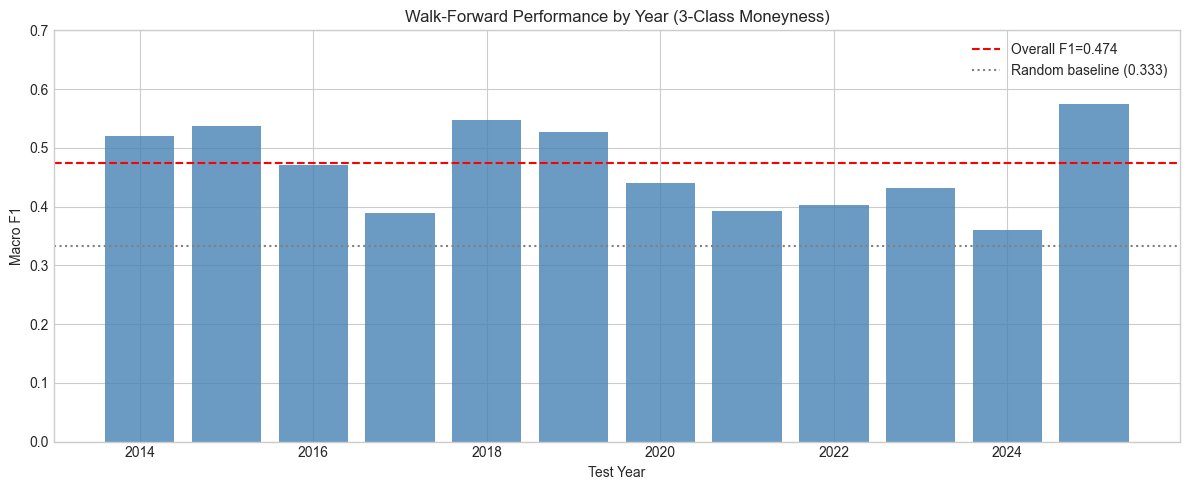

In [11]:
# Per-year performance
fold_df = pd.DataFrame(fold_results)
print("Per-Year Walk-Forward Performance:")
print(fold_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(fold_df['test_year'], fold_df['macro_f1'], color='steelblue', alpha=0.8)
ax.axhline(y=wf_f1, color='red', linestyle='--', label=f'Overall F1={wf_f1:.3f}')
ax.axhline(y=1/3, color='gray', linestyle=':', label='Random baseline (0.333)')
ax.set_xlabel('Test Year')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward Performance by Year (3-Class Moneyness)')
ax.legend()
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.savefig('../reports/figures/walkforward_yearly_f1.png', dpi=150)
plt.show()

## 5. Walk-Forward with Multiple Models

In [12]:
# Compare RF, XGB, LGBM in walk-forward
model_configs = {
    'RF': lambda cw: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight=cw, random_state=SEED, n_jobs=-1),
    'XGB': lambda cw: XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        random_state=SEED, use_label_encoder=False,
        eval_metric='mlogloss', n_jobs=-1),
    'LGBM': lambda cw: LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=50, subsample=0.8, colsample_bytree=0.7,
        min_child_samples=20, class_weight=cw,
        random_state=SEED, verbose=-1, n_jobs=-1),
}

wf_results = {}

for model_name, model_fn in model_configs.items():
    preds_all, true_all = [], []

    for test_year in test_years:
        train_mask = data['year'] < test_year
        test_mask = data['year'] == test_year
        if train_mask.sum() < 50:
            continue

        X_tr = data.loc[train_mask, feature_cols]
        y_tr = data.loc[train_mask, 'label_3']
        X_te = data.loc[test_mask, feature_cols]
        y_te = data.loc[test_mask, 'label_3']

        cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_tr)
        cw_dict = dict(enumerate(cw))

        if model_name == 'XGB':
            model = model_fn(cw_dict)
            sw = compute_sample_weight('balanced', y_tr)
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            model = model_fn(cw_dict)
            model.fit(X_tr, y_tr)

        preds_all.extend(model.predict(X_te))
        true_all.extend(y_te.values)

    preds_all = np.array(preds_all)
    true_all = np.array(true_all)

    acc = accuracy_score(true_all, preds_all)
    f1 = f1_score(true_all, preds_all, average='macro')

    wf_results[model_name] = {'Accuracy': acc, 'Macro F1': f1}
    print(f"{model_name}: Accuracy={acc:.4f}, Macro F1={f1:.4f}")

wf_df = pd.DataFrame(wf_results).T
print(f"\nBest model: {wf_df['Macro F1'].idxmax()}")

RF: Accuracy=0.5384, Macro F1=0.4733


XGB: Accuracy=0.5333, Macro F1=0.4656


LGBM: Accuracy=0.5384, Macro F1=0.4736

Best model: LGBM


## 6. Confusion Matrix and Top-2 Accuracy

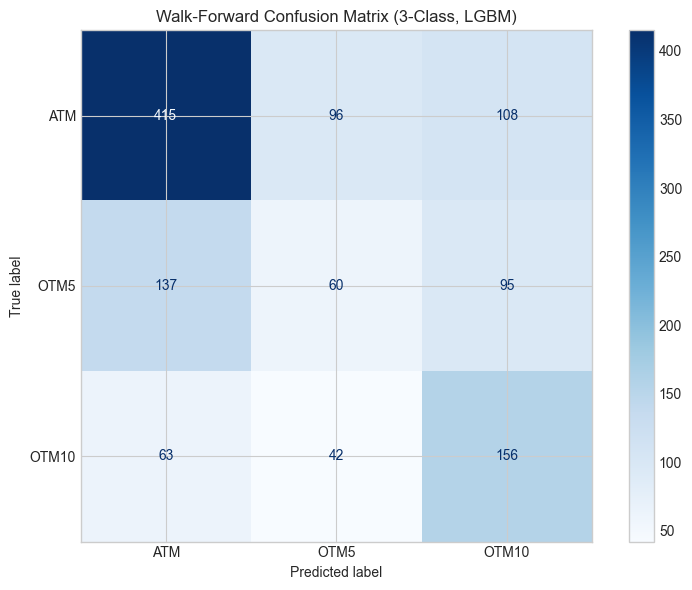

Top-1 Accuracy: 0.5384
Top-2 Accuracy: 0.8097


In [13]:
# Confusion matrix for LGBM (walk-forward)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['ATM', 'OTM5', 'OTM10'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Walk-Forward Confusion Matrix (3-Class, LGBM)')
plt.tight_layout()
plt.savefig('../reports/figures/walkforward_confusion_matrix.png', dpi=150)
plt.show()

# Top-2 accuracy
top2 = np.argsort(all_proba, axis=1)[:, -2:]
top2_correct = np.array([all_true[i] in top2[i] for i in range(len(all_true))])
print(f"Top-1 Accuracy: {wf_acc:.4f}")
print(f"Top-2 Accuracy: {top2_correct.mean():.4f}")

## 7. Feature Importance

Top 20 Features:
            feature  importance
          iv_change        1142
             mom_5d        1131
            mom_21d        1127
       volume_ratio        1076
     price_to_sma21        1074
            iv_skew        1041
earnings_growth_yoy         954
  iv_term_structure         942
     debt_to_equity         926
       gross_margin         907
          fcf_yield         898
          ev_ebitda         891
         cash_ratio         887
            vol_21d         886
           ps_ratio         885
            iv_rank         878
            mom_63d         872
    price_to_sma200         862
           pe_ratio         815
       iv_short_std         773

IV features ranking:
  iv_change: rank 1/34, importance=1142.0000
  iv_skew: rank 6/34, importance=1041.0000
  iv_term_structure: rank 8/34, importance=942.0000
  iv_rank: rank 16/34, importance=878.0000
  iv_short_std: rank 20/34, importance=773.0000
  iv_long_mean: rank 24/34, importance=730.0000
  iv_short

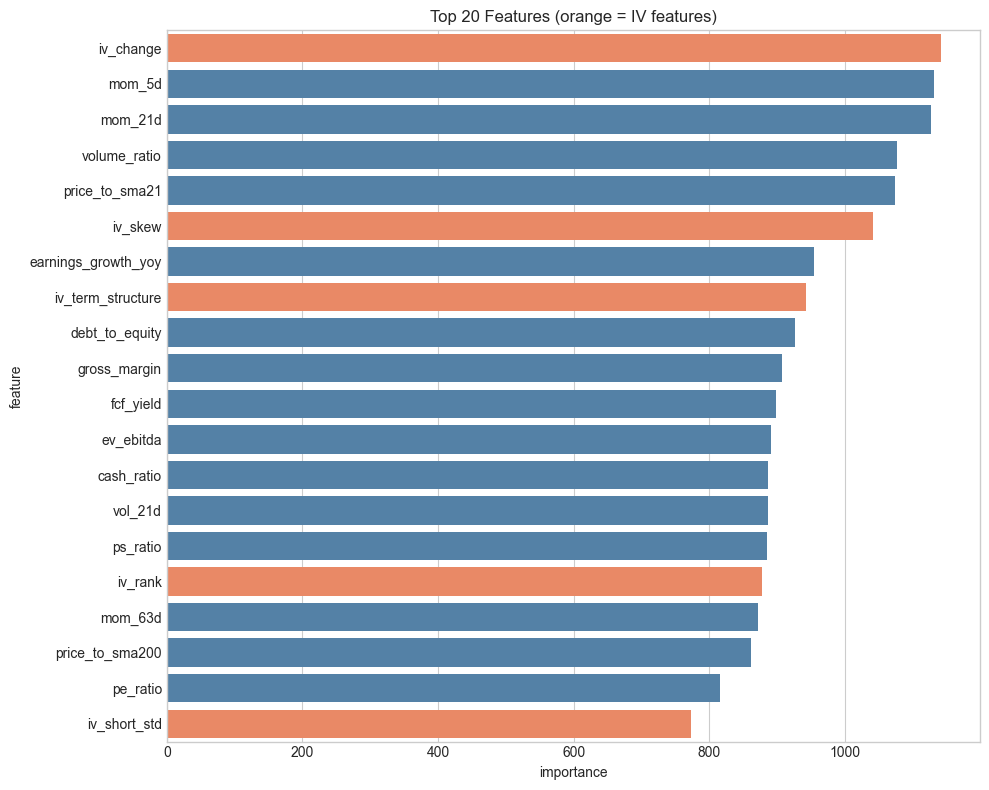

In [14]:
# Train final model on all data except last year for feature importance
final_train = data[data['year'] < 2025]
final_model = LGBMClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    num_leaves=50, subsample=0.8, colsample_bytree=0.7,
    min_child_samples=20, class_weight='balanced',
    random_state=SEED, verbose=-1, n_jobs=-1
)
final_model.fit(final_train[feature_cols], final_train['label_3'])

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Features:")
print(importance.head(20).to_string(index=False))

# Highlight IV features
iv_feats = importance[importance['feature'].str.startswith('iv_')]
print(f"\nIV features ranking:")
for _, row in iv_feats.iterrows():
    rank = (importance['importance'] >= row['importance']).sum()
    print(f"  {row['feature']}: rank {rank}/{len(feature_cols)}, importance={row['importance']:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance.head(20)
colors = ['coral' if f.startswith('iv_') else 'steelblue' for f in top20['feature']]
sns.barplot(data=top20, x='importance', y='feature', palette=colors, ax=ax)
ax.set_title('Top 20 Features (orange = IV features)')
plt.tight_layout()
plt.savefig('../reports/figures/improved_feature_importance.png', dpi=150)
plt.show()

## 8. Financial Return Evaluation

In [15]:
# Load bucket-level returns
daily_raw = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
daily_raw = daily_raw[daily_raw['symbol'].isin(UNIVERSE)].copy()
daily_raw['date'] = pd.to_datetime(daily_raw['date'])

calls_eval = options[options['call_put'] == 'CALL'].copy()
calls_eval = calls_eval[calls_eval['symbol'].isin(UNIVERSE)].copy()
calls_eval['expiration'] = pd.to_datetime(calls_eval['expiration'])
calls_eval['trade_date'] = pd.to_datetime(calls_eval['trade_date'])
calls_eval['dte'] = (calls_eval['expiration'] - calls_eval['trade_date']).dt.days

# Assign moneyness buckets
def assign_moneyness(delta):
    if 0.15 <= delta < 0.30: return 'OTM10'
    elif 0.30 <= delta < 0.45: return 'OTM5'
    elif 0.45 <= delta <= 0.60: return 'ATM'
    return None

calls_eval['moneyness'] = calls_eval['delta'].apply(assign_moneyness)
calls_eval = calls_eval.dropna(subset=['moneyness']).copy()

# Merge prices
daily_prices = daily_raw[['symbol', 'date', 'adjusted_close']].rename(columns={'adjusted_close': 'price'}).sort_values(['symbol', 'date'])
calls_eval = calls_eval.merge(
    daily_prices.rename(columns={'date': 'trade_date', 'price': 'entry_price'}),
    on=['symbol', 'trade_date'], how='left'
)

daily_exit = daily_prices.rename(columns={'date': 'expiration', 'price': 'exit_price'})
result_list = []
for sym in UNIVERSE:
    left = calls_eval[calls_eval['symbol'] == sym].sort_values('expiration')
    right = daily_exit[daily_exit['symbol'] == sym].sort_values('expiration')
    merged = pd.merge_asof(left, right[['expiration', 'exit_price']], on='expiration', direction='backward')
    result_list.append(merged)
calls_eval = pd.concat(result_list, ignore_index=True)

# Compute payoff
calls_eval['premium'] = calls_eval['mark'].fillna((calls_eval['bid'] + calls_eval['ask']) / 2)
calls_eval['stock_pnl'] = np.minimum(calls_eval['exit_price'], calls_eval['strike']) - calls_eval['entry_price']
calls_eval['return'] = (calls_eval['premium'] + calls_eval['stock_pnl']) / calls_eval['entry_price']
calls_eval = calls_eval[(calls_eval['return'] > -0.5) & (calls_eval['return'] < 0.5)].copy()
calls_eval = calls_eval[(calls_eval['entry_price'] > 0) & (calls_eval['premium'] > 0)].copy()

# Monthly returns by moneyness
calls_eval['year_month'] = calls_eval['trade_date'].dt.to_period('M')
moneyness_returns = calls_eval.groupby(['symbol', 'year_month', 'moneyness'])['return'].mean().reset_index()

print(f"Moneyness return observations: {len(moneyness_returns):,}")

Moneyness return observations: 3,900


In [16]:
# Map walk-forward predictions to financial returns
meta_df = pd.DataFrame(all_meta)
meta_df['pred'] = all_preds
meta_df['true'] = all_true
meta_df['year_month'] = pd.to_datetime(meta_df['decision_date']).dt.to_period('M')

label_to_moneyness = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}

def get_returns(df, pred_col, returns_df):
    rets = []
    for _, row in df.iterrows():
        bucket = label_to_moneyness[row[pred_col]]
        match = returns_df[
            (returns_df['symbol'] == row['symbol']) &
            (returns_df['year_month'] == row['year_month']) &
            (returns_df['moneyness'] == bucket)
        ]
        rets.append(match['return'].values[0] if len(match) > 0 else np.nan)
    return np.array(rets)

model_returns = get_returns(meta_df, 'pred', moneyness_returns)
oracle_returns = get_returns(meta_df, 'true', moneyness_returns)

# Static: always ATM
meta_df['static_atm'] = 0
static_returns = get_returns(meta_df, 'static_atm', moneyness_returns)

# Random: average across all moneyness buckets
random_returns = []
for _, row in meta_df.iterrows():
    match = moneyness_returns[
        (moneyness_returns['symbol'] == row['symbol']) &
        (moneyness_returns['year_month'] == row['year_month'])
    ]
    random_returns.append(match['return'].mean() if len(match) > 0 else np.nan)
random_returns = np.array(random_returns)

print("Financial return lookup complete.")

Financial return lookup complete.


In [17]:
# Financial summary
def summarize(returns, name):
    valid = returns[~np.isnan(returns)]
    if len(valid) == 0:
        return {'Strategy': name, 'Mean Monthly': 'N/A', 'Std': 'N/A', 'Sharpe': 'N/A', 'N': 0}
    m = np.mean(valid)
    s = np.std(valid)
    sharpe = m / s * np.sqrt(12) if s > 0 else 0
    return {
        'Strategy': name,
        'Mean Monthly': f'{m:.4f}',
        'Std': f'{s:.4f}',
        'Annualized Sharpe': f'{sharpe:.2f}',
        'N': len(valid)
    }

fin_df = pd.DataFrame([
    summarize(oracle_returns, 'Oracle (best moneyness)'),
    summarize(model_returns, 'LGBM Walk-Forward'),
    summarize(static_returns, 'Static (always ATM)'),
    summarize(random_returns, 'Random (avg all)'),
])

print("Financial Performance (Walk-Forward, 2014-2025):")
print(fin_df.to_string(index=False))

Financial Performance (Walk-Forward, 2014-2025):
               Strategy Mean Monthly    Std Annualized Sharpe    N
Oracle (best moneyness)       0.2256 0.1570              4.98 1172
      LGBM Walk-Forward       0.2002 0.1516              4.58 1147
    Static (always ATM)       0.2098 0.1620              4.49 1040
       Random (avg all)       0.1879 0.1371              4.75 1172


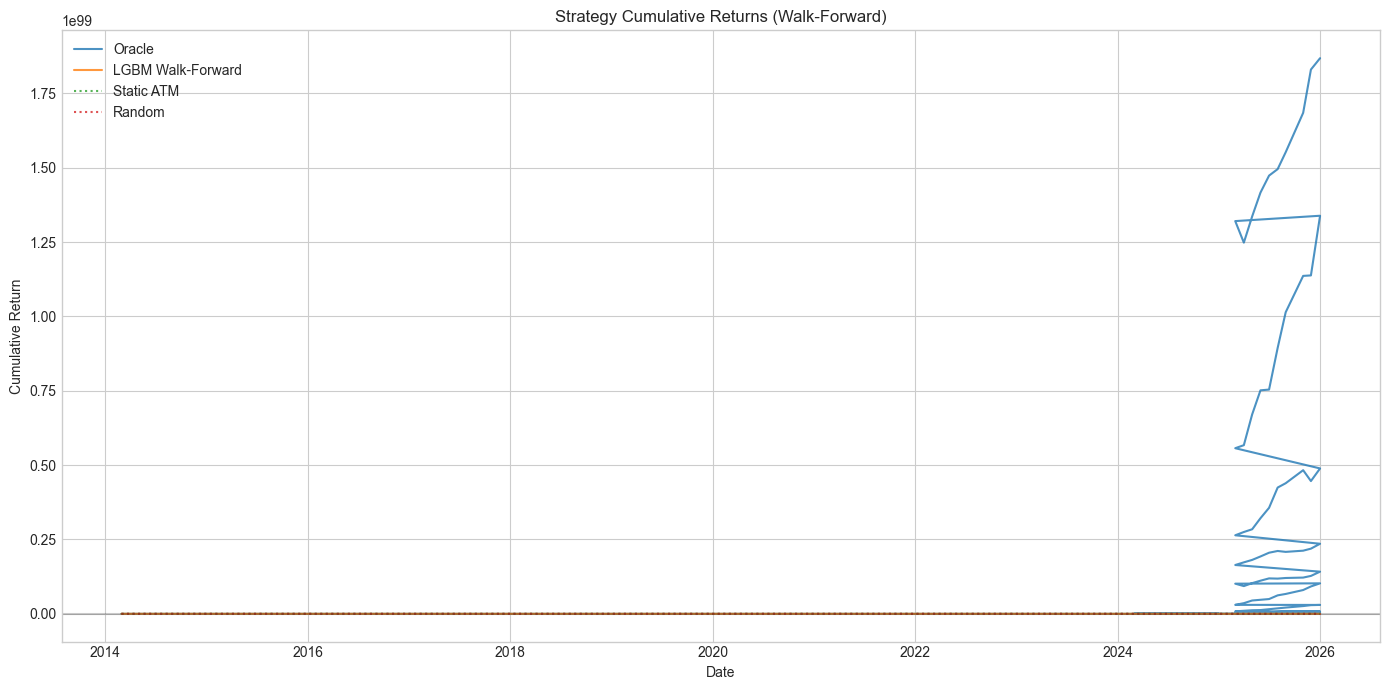

In [18]:
# Cumulative return comparison
fig, ax = plt.subplots(figsize=(14, 7))

dates = pd.to_datetime(meta_df['decision_date'].values)

for rets, name, style in [
    (oracle_returns, 'Oracle', '-'),
    (model_returns, 'LGBM Walk-Forward', '-'),
    (static_returns, 'Static ATM', ':'),
    (random_returns, 'Random', ':'),
]:
    cum = np.cumprod(1 + np.nan_to_num(rets, nan=0))
    ax.plot(dates, cum, label=name, linestyle=style, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.set_title('Strategy Cumulative Returns (Walk-Forward)')
ax.legend(loc='upper left')
ax.axhline(y=1, color='black', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.savefig('../reports/figures/financial_returns_comparison.png', dpi=150)
plt.show()

## 9. Summary

In [19]:
print("=" * 60)
print("IMPROVED MODEL RESULTS")
print("=" * 60)

print(f"\nApproach:")
print(f"  Target: 3-class moneyness (ATM/OTM5/OTM10)")
print(f"  Maturity: rule-based (IV rank > 0.5 -> SHORT, else LONG)")
print(f"  Validation: walk-forward (annual expanding window)")
print(f"  Imbalance: class weights (no SMOTE)")
print(f"  IV features added: {len([c for c in feature_cols if c.startswith('iv_')])}")

print(f"\nClassification (Walk-Forward):")
print(f"  Macro F1:      {wf_f1:.4f}")
print(f"  Accuracy:      {wf_acc:.4f}")
print(f"  Top-2 Accuracy: {top2_correct.mean():.4f}")

print(f"\nAll Models (Walk-Forward):")
for name, metrics in wf_results.items():
    print(f"  {name}: Acc={metrics['Accuracy']:.4f}, F1={metrics['Macro F1']:.4f}")

print(f"\nMaturity rule accuracy: {rule_accuracy:.4f}")

print(f"\nFinancial Performance:")
print(fin_df[['Strategy', 'Mean Monthly', 'Annualized Sharpe']].to_string(index=False))

IMPROVED MODEL RESULTS

Approach:
  Target: 3-class moneyness (ATM/OTM5/OTM10)
  Maturity: rule-based (IV rank > 0.5 -> SHORT, else LONG)
  Validation: walk-forward (annual expanding window)
  Imbalance: class weights (no SMOTE)
  IV features added: 9

Classification (Walk-Forward):
  Macro F1:      0.4736
  Accuracy:      0.5384
  Top-2 Accuracy: 0.8097

All Models (Walk-Forward):
  RF: Acc=0.5384, F1=0.4733
  XGB: Acc=0.5333, F1=0.4656
  LGBM: Acc=0.5384, F1=0.4736

Maturity rule accuracy: 0.6190

Financial Performance:
               Strategy Mean Monthly Annualized Sharpe
Oracle (best moneyness)       0.2256              4.98
      LGBM Walk-Forward       0.2002              4.58
    Static (always ATM)       0.2098              4.49
       Random (avg all)       0.1879              4.75


## 10. Save Models

In [20]:
# Save final model (trained on all data except 2025)
joblib.dump(final_model, MODELS / 'lgbm_3class_moneyness.joblib')

metadata = {
    'feature_cols': feature_cols,
    'moneyness_map': {'ATM': 0, 'OTM5': 1, 'OTM10': 2},
    'maturity_rule': 'SHORT if iv_rank > 0.5 else LONG',
    'approach': 'walk-forward, class weights, IV features, 3-class moneyness',
    'walk_forward_f1': wf_f1,
    'walk_forward_acc': wf_acc,
}
with open(MODELS / 'improved_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Models and metadata saved.")

Models and metadata saved.
